In [21]:
import sys
import os
import csv
import yaml

import math
import pandas as pd
import numpy as np
from scipy import signal
from scipy.signal import butter, filtfilt
import statistics as st
import matplotlib.pyplot as plt
import json
import random

samples = 211

data_path = './data'
gravity_acceleration = 9.806
cutoff = 2

In [22]:
def vect_length(vector):
    """
        Length of an euclidean vector of 2 and 3 dimensions
        Input:
            vector is an list
    """

    return math.sqrt(sum([math.pow(component, 2) for component in vector]))

def orientation(vector):
    """
        Unit vector of an euclidean vector of 2 and 3 dimensions
        Input:
            vector is an list
    """

    vector_len = vect_length(vector)

    return [component/vector_len for component in vector]

def Euler(dt, dx):
    """
        Euler's method:
            First Order Differentional Equation Resolution
            Stating nul vector as initial condition
        Input:
            dt - non-fix time steps list
            dx - x derivative in order of t
    """

    xx = [[0.0, 0.0, 0.0]]

    for ii in range(1,len(dt)):
        xx = xx + [[xx[-1][0] + dt[ii] * dx[ii - 1][0], \
                  xx[-1][1] + dt[ii] * dx[ii - 1][1], \
                  xx[-1][2] + dt[ii] * dx[ii - 1][2]]]

    return xx

def Esc_Prod(list01, list02):
    """
        Escalar Product between two euclidean vectors of 2 and 3 dimensions
        Input:
            list01 is an list of a list
            list02 is an list of a list
    """

    return [sum([comp01*comp02 for comp01,comp02 in zip(vect01,vect02)]) for vect01,vect02 in zip(list01, list02)]

def RoundFloat(List):

    for ii in range(len(List)):
        if isinstance(List[ii], float):
            List[ii] = float(f'{(List[ii] + 0.0005):.4f}')
        elif isinstance(List[ii], list):
            list01 = [float(f'{(element + 0.0005):.4f}') for element in List[ii] if isinstance(List[ii], float)]
            if len(list01) > 0:
                List[ii] = list01

    return List

In [23]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def accelerometer(exp_data):
    ### Accelerometer Data Extraction
    Acelerometer_data = exp_data['accelerometer']
    Meter_Time = [data[0] for data in Acelerometer_data]
    Exp_Acceleration = [data[1] for data in Acelerometer_data]

    # Time variables
    Experiment_Tt_Time = (Meter_Time[-1] - Meter_Time[0]) * 1.0e-3
    Experiment_Time = [(Meter_Time[ii] - Meter_Time[0]) * 1e-3 for ii in range(len(Meter_Time))]
    Time_Interv = [0.0] + [(Meter_Time[ii] - Meter_Time[ii - 1]) * 1e-3 for ii in range(1, len(Meter_Time))]

    # Unit conversion: Apply gravity to convert to meters per second squared
    Converted_Accel = [[element * gravity_acceleration * 0.001 for element in line] for line in Exp_Acceleration]
    Orient_ot_acceleration = [orientation(line) for line in Converted_Accel]

    # Remove Gravity
    Corrected_Accel = []
    for component, grav_comp in zip(Converted_Accel, Orient_ot_acceleration):
        Corrected_Accel = Corrected_Accel + [[line1 - gravity_acceleration * line2 for line1, line2 in zip(component, grav_comp)]]

    # Apply Butterworth low-pass filter
    fs = 1 / Time_Interv[1]  # Sampling frequency
    Corrected_Accel_flt = [butter_lowpass_filter([accel[i] for accel in Corrected_Accel], cutoff, fs) for i in range(3)]

    # Rebuild Corrected_Accel with the filtered data
    Corrected_Accel = [[Corrected_Accel_flt[0][i], Corrected_Accel_flt[1][i], Corrected_Accel_flt[2][i]] for i in range(len(Corrected_Accel_flt[0]))]

    # Calculate Magnitude (Vector Length)
    Corrected_Accel_Int = [vect_length(line) for line in Corrected_Accel]

    # Detect Steps (Peaks)
    Peeks_Loc = [Time_ind for Time_ind in range(1, len(Corrected_Accel_Int) - 1)
                 if (((Corrected_Accel_Int[Time_ind] - Corrected_Accel_Int[Time_ind - 1]) > 0) &
                     ((Corrected_Accel_Int[Time_ind + 1] - Corrected_Accel_Int[Time_ind]) < 0) &
                     (Corrected_Accel_Int[Time_ind] > (st.fmean(Corrected_Accel_Int) + st.stdev(Corrected_Accel_Int) / 3)))]

    Num_Steps = len(Peeks_Loc)

    # --- PLOTTING SECTION ---
    # Create just one figure for the Accelerometer
    plt.figure(figsize=(16, 6))

    # Plot the main acceleration line
    plt.plot(Experiment_Time, Corrected_Accel_Int, label='Filtered Acceleration', color='blue', linewidth=1)

    # Plot the detected steps as red dots
    plt.scatter([Experiment_Time[j] for j in Peeks_Loc],
                [Corrected_Accel_Int[j] for j in Peeks_Loc],
                color='red', marker='o', label='Detected Steps')

    plt.title("Filtered Accelerometer Magnitude")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration (m/s^2)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- CALCULATIONS (Steps) ---
    # Note: Speed/Distance removed as requested to focus on Accelerometer
    try:
        Mean_Step_Time = st.fmean([((Meter_Time[Peeks_Loc[ii]] - Meter_Time[Peeks_Loc[ii-1]])*1.0e-3) for ii in range(1, Num_Steps)])
        STD_Step_Time = st.stdev([((Meter_Time[Peeks_Loc[ii]] - Meter_Time[Peeks_Loc[ii-1]])*1.0e-3) for ii in range(1, Num_Steps)], Mean_Step_Time)

        # Adjust Interval logic
        step = 1; lower_limit = Peeks_Loc[0]
        while ((lower_limit - step) >= 0) & (Experiment_Time[lower_limit] - Experiment_Time[lower_limit - step] < Mean_Step_Time/2):
            Peeks_Loc = [Peeks_Loc[0] - 1] + Peeks_Loc
            step = step +1
        step = 1; higher_limit = Peeks_Loc[-1]
        while ((higher_limit + step) < (len(Experiment_Time) - 1)) & ((Experiment_Time[higher_limit + step] - Experiment_Time[higher_limit]) < Mean_Step_Time/2):
            Peeks_Loc = Peeks_Loc + [Peeks_Loc[-1] + 1]
            step = step +1
        Study_Interval = [Meter_Time[Peeks_Loc[0]], Meter_Time[Peeks_Loc[-1]]]
    except (st.StatisticsError, IndexError):
        # Handle cases with no steps or calculation errors
        Mean_Step_Time = 0
        STD_Step_Time = 0
        Study_Interval = [0, 0]

    # Return Step data, fill others with 0/NA since we removed velocity math
    return RoundFloat([Experiment_Tt_Time, Num_Steps, Mean_Step_Time, STD_Step_Time, 0, 0, 0, 0, Study_Interval])


Sample User Characteristics:
User Id: 98
User Age: 25


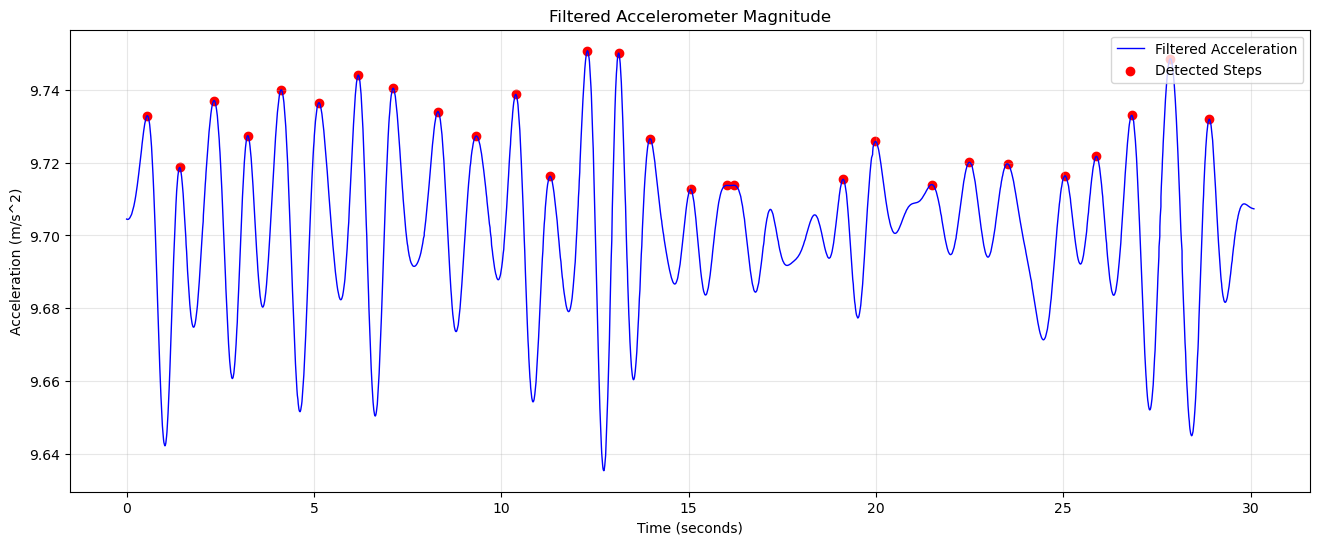

In [24]:
### read all files for random sample and print info
a = random.randint(1,samples)
sample_path = os.path.join(data_path,str(a))
json_path = os.path.join(sample_path,'user_data.json')
#read data and visualize
with open(json_path, 'r', encoding= 'utf-8') as f:
    sample_data =  json.load(f)
    user_id = sample_data['user_id']
    user_age = sample_data['age']
    user_weight = sample_data['weight_kg']
    user_height = sample_data['height_cm']
    user_gender = sample_data['gender']
    phone_location = sample_data['phone_location']
    high_height_cm = sample_data['high_height_cm']
    print("Sample User Characteristics:")
    print("User Id:",user_id)
    print("User Age:",user_age)

    data_values={}
    accel_file = sample_path + '/' + 'accelerometer.txt'
    with open(accel_file, 'r') as f:
        accel_data = f.readlines()
        data_values['accelerometer'] = []
        for time_instant in accel_data[1:]:
            time_instant = time_instant.split()
            data_values['accelerometer'] = data_values['accelerometer'] + \
                    [[eval(time_instant[0]), [eval(component) for component in time_instant[1:]]]]
        ### Accelerometer
        AccelResults = accelerometer(data_values)